# Multi-layer perceptron neural network to use physicochemical descriptors to predict log binding affinity

### Load the data:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

Xtrain = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/Xtrainfeatnew.csv', index_col=0)
Xtest = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/Xtestfeatnew.csv', index_col=0)
X = pd.concat([Xtrain, Xtest])
X = X.sort_values(by='Index_original')
X_csv = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
data = X.join(X_csv['PDB_Code'])
data = data.join(X_csv['Log_binding'])
display(data)

,MolecularWeight,Aromaticity,InstabilityIndex,Gravy,MoreauBrotoAuto_Hydrophobicity1,MoreauBrotoAuto_Hydrophobicity2,MoreauBrotoAuto_Hydrophobicity3,MoreauBrotoAuto_Hydrophobicity4,MoreauBrotoAuto_Hydrophobicity5,MoreauBrotoAuto_Hydrophobicity6,...,MolLogP,NumHAcceptors,NumHDonors,NumRotatableBonds,RingCount,LabuteASA,Kappa1,BalabanJ,PDB_Code,Log_binding
Index_original,,,,,,,,,,,,,,,,,,,,,
0,28890.2555,0.105058,20.111284,-0.577432,-0.069,-0.066,-0.061,-0.062,-0.063,-0.059,...,1.16380,3,2,0,2,85.115803,9.291447,2.755753,6ugp,6.16
1,17325.4941,0.114094,35.021477,-0.654362,0.093,0.097,0.105,0.105,0.107,0.088,...,-1.52050,9,4,3,3,113.421074,13.185962,2.031041,4rdn,5.92
2,74371.0384,0.059163,44.232179,0.015729,-0.010,-0.010,-0.010,-0.010,-0.011,-0.011,...,-2.28750,14,3,6,3,151.244978,20.269054,1.748652,4mo4,4.22
3,13535.4695,0.042017,37.857983,-0.388235,-0.035,-0.046,-0.034,-0.024,-0.014,-0.020,...,4.58340,1,1,2,3,100.720024,9.911594,2.063095,3s0b,6.49
4,11850.3812,0.141509,37.638679,-0.111321,0.005,0.004,0.004,0.001,-0.011,-0.012,...,0.32790,4,2,3,2,103.313061,12.096595,1.791206,6r1d,5.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5244,129734.0766,0.075758,40.627189,-0.085606,-0.013,-0.012,-0.010,-0.010,-0.010,-0.011,...,2.19470,4,2,3,4,153.499718,17.045406,1.809687,6p3t,7.32
5245,23305.0899,0.076233,22.296861,-0.059641,0.047,0.043,0.043,0.044,0.051,0.046,...,-1.95550,2,2,2,1,76.357033,9.964175,3.080437,1tx7,4.60
5246,35893.3613,0.033537,22.086890,-0.063720,0.019,0.019,0.019,0.019,0.019,0.019,...,-2.57180,15,3,6,3,149.085055,19.947729,1.757685,3ta1,3.25


In [2]:
X = X.values
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# pca = PCA(0.80) # keep 80% of the variance of the data
# pca.fit(X)
# X = pca.transform(X)
# print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

# display(X)
y = data['Log_binding'].values.reshape(-1,1)
# display(y)

In [3]:
# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [4]:
# Detect GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Defining the MLP model:

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate, num_hidden_layers=2):
        super(MLP, self).__init__()
        
        self.hidden_layers = nn.ModuleList()

        # First hidden layer
        self.hidden_layers.append(nn.Linear(input_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Second hidden layer
        self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Third hidden layer (if num_hidden_layers == 3)
        if num_hidden_layers == 3:
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))

        # Output layer
        self.output_layer = nn.Linear(hidden_dim, 1)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        for i in range(0, len(self.hidden_layers), 2): # to skip the BatchNorm element
            x = torch.relu(self.hidden_layers[i+1](self.hidden_layers[i](x)))
            # Using ReLU activation function (common, helps prevent vanishing gradient)
            # Sigmoid outpus value between 0 - 1 so not useful for predicting affinity value
            # Tanh also outputs between -1 and 1
            # Leaky ReLU also exists for negative inputs, but all log affinity values btw 2 and 12
            x = self.dropout(x)

        x = self.output_layer(x)  # No activation for regression
        return x

### Defining the training function - uses early stopping

In [6]:
def train(model, train_loader, val_loader, criterion, optimizer, patience=10, epochs=50): # patience for early stopping over N epochs
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train() # Forward pass through the neural network layers (with batch normalisation and dropout regularisation)
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad() # Clear the previous gradients (for proper calculations)
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch.squeeze()) # Calculate the loss
            loss.backward() # Compute the gradients (backpropagation)
            optimizer.step() # Update weights (by the optimzer object)
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval() # Evaluation mode, changes behaviour of layers (dropout and batch normalization)
        val_loss = 0

        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                y_val_pred = model(X_val_batch).squeeze()
                loss = criterion(y_val_pred, y_val_batch.squeeze())
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # ---- Early Stopping Check ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break

    return epoch_losses  # Return loss curve for plotting

## Nested CV - 5 outer 3 inner folds 

In [11]:
param_grid = {
    "hidden_dim": [62, 128, 256, 512], # Neurons per hidden layer, more = more complex representations
    "dropout_rate": [0.1, 0.2, 0.3, 0.4],
    "learning_rate": [0.1, 0.01, 0.005, 0.001], # Step size at each iteration moving toward minimum of loss function - during optimisation
    "num_hidden_layers": [2, 3]
    # batch size 16, 32, 62, 128 - smaller batches more updates but noisier gradients, larger require more memory
    # optimizer SGD basic optimzer, Adam adaptive learning rate
    # weight initialization: Xavier/Glorot Initialisation, He initialisation, Uniform/Normal distribution
    # number of epochs - under or overfitting
    # L1 (absolute val) or L2 (squared val) regularisation adds penalty to large weignts, prevent overfitting
}

# ---- Outer Loop ----
outer_kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_loss_curves = []

results = [] # Store results

for fold, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    print(f"Outer Fold {fold+1}/5")
    
    random_params = [
    {key: random.choice(values) for key, values in param_grid.items()} 
    for _ in range(3)
    ]
    
    # print("random_params for this outer fold:", random_params)

    X_train_outer, X_test_outer = X[train_idx], X[test_idx]
    y_train_outer, y_test_outer = y[train_idx], y[test_idx]

    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)
    best_params = None
    best_val_loss = float("inf")
    
    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        # print("Using hyperparams", params)
        
        val_losses = []

        for train_inner_idx, val_idx in inner_kf.split(X_train_outer):
            X_train_inner, X_val = X_train_outer[train_inner_idx], X_train_outer[val_idx]
            y_train_inner, y_val = y_train_outer[train_inner_idx], y_train_outer[val_idx]

            train_loader = DataLoader(TensorDataset(X_train_inner, y_train_inner), batch_size=32, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

            model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=params["hidden_dim"], 
                dropout_rate=params["dropout_rate"], 
                num_hidden_layers=params["num_hidden_layers"]).to(device)
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=1e-5)

            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)
            val_losses.append(min(epoch_losses))

        mean_val_loss = np.mean(val_losses)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")
    
    # ---- Train Final Model with Best Hyperparams ----
    train_loader = DataLoader(TensorDataset(X_train_outer, y_train_outer), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_outer, y_test_outer), batch_size=64, shuffle=False)

    model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=best_params["hidden_dim"], 
                dropout_rate=best_params["dropout_rate"], 
                num_hidden_layers=best_params["num_hidden_layers"]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=1e-5)

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer, epochs=50)
    all_loss_curves.append(epoch_losses)
    
    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).squeeze().cpu().numpy()
            y_true = y_batch.squeeze().cpu().numpy()

            y_pred_list.extend(y_pred)
            y_true_list.extend(y_true)

    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({"Fold": fold+1, "Pearson": pearson_corr, "Pearson p": pearson_p, "Spearman": spearman_corr, "Spearman p": spearman_p, "MAE": mae, "Variance": variance, "R2": r2})

Outer Fold 1/5
Early stopping after 50 epochs
Early stopping after 43 epochs
Best hyperparams for Fold 1: {'hidden_dim': 256, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'num_hidden_layers': 2}
Early stopping after 46 epochs
Outer Fold 2/5
Early stopping after 38 epochs
Early stopping after 41 epochs
Early stopping after 46 epochs
Early stopping after 26 epochs
Early stopping after 35 epochs
Early stopping after 34 epochs
Early stopping after 41 epochs
Best hyperparams for Fold 2: {'hidden_dim': 512, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'num_hidden_layers': 2}
Outer Fold 3/5
Early stopping after 47 epochs
Early stopping after 22 epochs
Early stopping after 48 epochs
Early stopping after 30 epochs
Early stopping after 33 epochs
Early stopping after 25 epochs
Early stopping after 37 epochs
Best hyperparams for Fold 3: {'hidden_dim': 256, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'num_hidden_layers': 3}
Early stopping after 47 epochs
Outer Fold 4/5
Early stopping after 34 epoch

In [12]:
print(results)

[{'Fold': 1, 'Pearson': 0.6796106658798957, 'Pearson p': 4.6204398164544145e-138, 'Spearman': 0.6702903031053131, 'Spearman p': 5.4870998290396965e-133, 'MAE': 1.1278845, 'Variance': 2.0822895, 'R2': 0.4473144324747679}, {'Fold': 2, 'Pearson': 0.6584146520713577, 'Pearson p': 8.765063477947476e-127, 'Spearman': 0.6649687329818089, 'Spearman p': 3.5850813798008862e-130, 'MAE': 1.1674289, 'Variance': 2.230308, 'R2': 0.3804308518908467}, {'Fold': 3, 'Pearson': 0.6826302004350455, 'Pearson p': 9.547856689593867e-140, 'Spearman': 0.6792603008417124, 'Spearman p': 7.225353035420489e-138, 'MAE': 1.1319199, 'Variance': 2.0564568, 'R2': 0.44471632233062386}, {'Fold': 4, 'Pearson': 0.7032810016219443, 'Pearson p': 7.692936993650711e-152, 'Spearman': 0.700896343059157, 'Spearman p': 2.1669944127463858e-150, 'MAE': 1.0961785, 'Variance': 1.9345177, 'R2': 0.4845743337235653}, {'Fold': 5, 'Pearson': 0.6926065261304595, 'Pearson p': 2.5549979355422476e-145, 'Spearman': 0.6935034169698636, 'Spearman p

In [13]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_mean}")
print(f"Variance: Mean = {var_mean}, Std = {var_mean}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.6833086092277405, Std = 0.01496122884709416, p-value Mean = 1.753012695598927e-127, p-value Std = 3.506025391174274e-127
Spearman Correlation: Mean = 0.6817838193915711, Std = 0.01359304029128789, p-value Mean = 7.181137103766914e-131, p-value Std = 1.4334854099644456e-130
MAE: Mean = 1.1411902904510498, Std = 1.1411902904510498
Variance: Mean = 2.077915906906128, Std = 2.077915906906128
R2: Mean = 0.43827338810051336, Std = 0.03355094892520532


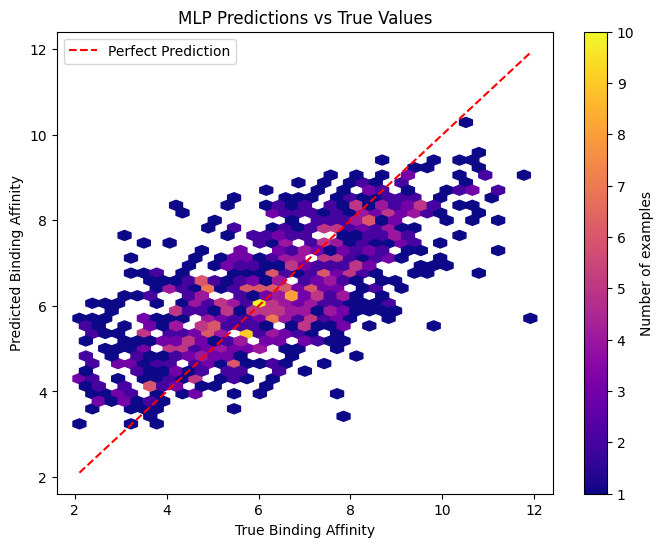

In [10]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("MLP Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

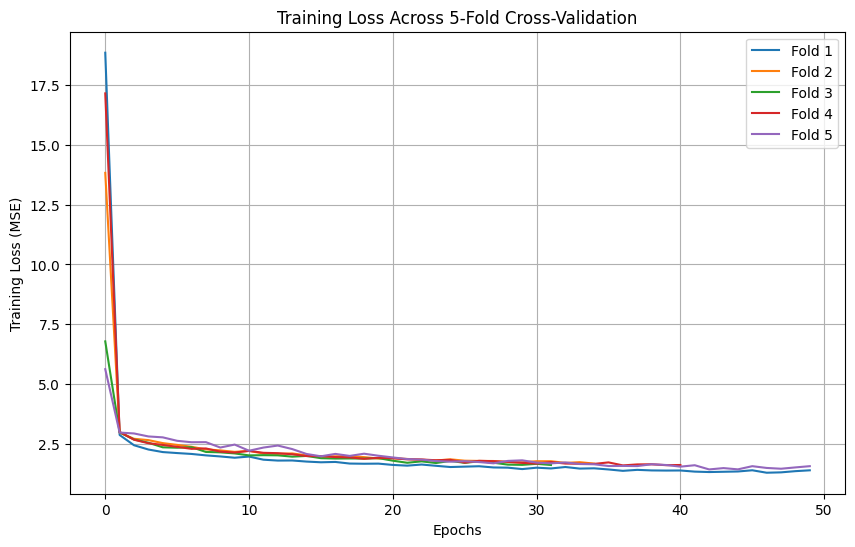

In [13]:
plt.figure(figsize=(10, 6))
for i, losses in enumerate(all_loss_curves):
    plt.plot(losses, label=f'Fold {i+1}')
plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Across 5-Fold Cross-Validation")
plt.legend()
plt.grid(True)
plt.show()